In [5]:
from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('../data/Telc_customer_churn_cleaned.csv')
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,avg_monthly_spend,has_multiple_services,Average Monthly Spend,Multiple Services
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,108.15,Yes,1,86,3239,Competitor made better offer,54.075000,True,54.075000,True
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,151.65,Yes,1,67,2701,Moved,75.825000,False,75.825000,False
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,820.50,Yes,1,86,5372,Moved,102.562500,True,102.562500,True
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,3046.05,Yes,1,84,5003,Moved,108.787500,True,108.787500,True
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,5036.30,Yes,1,89,5340,Competitor had better devices,102.781633,True,102.781633,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,1419.40,No,0,45,5306,NaN,19.713889,False,19.713889,False
7028,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,1990.50,No,0,59,2140,NaN,82.937500,True,82.937500,True
7029,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,7362.90,No,0,71,5560,NaN,102.262500,True,102.262500,True
7030,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,346.45,No,0,59,2793,NaN,31.495455,False,31.495455,False


In [4]:
df['Payment Method'].unique()

<StringArray>
[             'Mailed check',          'Electronic check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [3]:
df_stayed = df[df['Churn Value'] == 0]
df_churned = df[df['Churn Value'] == 1]

In [11]:
table = pd.crosstab(index=df['Churn Value'], columns=df['Tech Support'])
chi2, p, dof, expected = chi2_contingency(table)
print(table)

Tech Support    No  No internet service   Yes
Churn Value                                  
0             2026                 1407  1730
1             1446                  113   310


### For each chi squared test, churn value would be the rows and categorial data would constitute the columns

In [13]:
from statsmodels.stats.multitest import multipletests

service_cols = ['Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing',
                'Contract', 'Payment Method', 'Gender', 'Multiple Services']

rows = []

# Tests for Indepencence for categories

def chi2_tests(df, cols, outcome='Churn Value'):
    rows = []
    tables = {}
    for col in cols:
        table = pd.crosstab(df[outcome], df[col])
        chi2, p, dof, expected = chi2_contingency(table)
        n = table.to_numpy().sum()
        r, c = table.shape
        k_minus_1 = min(r - 1, c - 1)
        cramers_v = (chi2 / (n * k_minus_1)) ** 0.5
        rows.append({'feature': col, 'chi2': chi2, 'p': p, 'cramers_v': cramers_v})
        tables[col] = {'table': table, 'expected': expected}  # stash for reuse
    return pd.DataFrame(rows), tables

rows, __ = chi2_tests(df, service_cols)
print(rows.sort_values(by='cramers_v', ascending=False))




              feature         chi2              p  cramers_v
8            Contract  1179.545829  7.326182e-257   0.409560
1     Online Security   846.677389  1.400687e-184   0.346992
4        Tech Support   824.925564  7.407808e-180   0.342506
9      Payment Method   645.429900  1.426310e-139   0.302960
2       Online Backup   599.175185  7.776099e-131   0.291902
3   Device Protection   555.880327  1.959389e-121   0.281159
6    Streaming Movies   374.268432   5.353560e-82   0.230702
5        Streaming TV   372.456502   1.324641e-81   0.230143
7   Paperless Billing   256.874908   8.236203e-58   0.191127
0      Multiple Lines    11.271541   3.567927e-03   0.040036
11  Multiple Services     7.659048   5.648829e-03   0.033003
10             Gender     0.475455   4.904885e-01   0.008223


In [10]:
def adjusted_residuals_from_expected(table, expected):
    """Compute adjusted residuals using a pre-computed expected array — no re-test."""
    obs = table.to_numpy()
    n = obs.sum()
    row_totals = obs.sum(axis=1, keepdims=True)
    col_totals = obs.sum(axis=0, keepdims=True)
    resid = obs - expected
    denom = np.sqrt(expected * (1 - row_totals / n) * (1 - col_totals / n))
    return pd.DataFrame(resid / denom, index=table.index, columns=table.columns)

results, tables = chi2_tests(df, service_cols)

for col in service_cols:
    adj_resid = adjusted_residuals_from_expected(tables[col]['table'], tables[col]['expected'])
    print(f"\n=== {col} ===")
    print(adj_resid.round(2))


=== Multiple Lines ===
Multiple Lines    No  No phone service   Yes
Churn Value                                 
0               2.74              0.98 -3.36
1              -2.74             -0.98  3.36

=== Online Security ===
Online Security    No  No internet service    Yes
Churn Value                                      
0               -28.7                19.08  14.36
1                28.7               -19.08 -14.36

=== Online Backup ===
Online Backup     No  No internet service  Yes
Churn Value                                   
0             -22.44                19.08  6.9
1              22.44               -19.08 -6.9

=== Device Protection ===
Device Protection     No  No internet service   Yes
Churn Value                                        
0                 -21.14                19.08  5.55
1                  21.14               -19.08 -5.55

=== Tech Support ===
Tech Support     No  No internet service    Yes
Churn Value                                    
0      

### Check for data normality

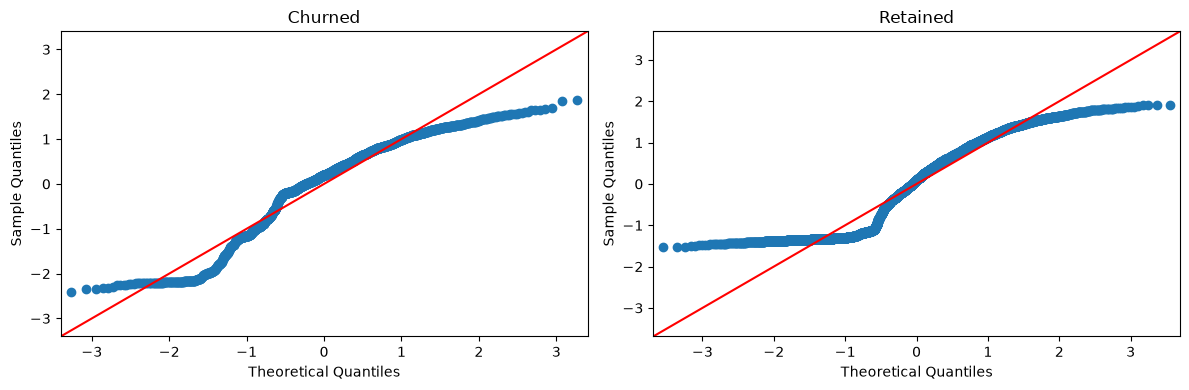

In [21]:
from matplotlib import pyplot as plt
from statsmodels.graphics.gofplots import qqplot

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

qqplot(df[df['Churn Value'] == 1]['Average Monthly Spend'],
       line='45', fit=True, ax=axes[0])
axes[0].set_title('Churned')

qqplot(df[df['Churn Value'] == 0]['Average Monthly Spend'],
       line='45', fit=True, ax=axes[1])
axes[1].set_title('Retained')

plt.tight_layout()

In [24]:
import scipy.stats as stats

avg_m_spend_x = df[df['Churn Value'] == 1]['Average Monthly Spend']
avg_m_spend_y = df[df['Churn Value'] == 0]['Average Monthly Spend']

t_stat, p_value = stats.ttest_ind(avg_m_spend_x, avg_m_spend_y, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value}")

T-statistic: 18.1745
P-value: 4.754563808455687e-71
